In [2]:
import pandas as pd
import numpy as np
from fastjsonschema.ref_resolver import normalize

In [3]:
data = pd.read_csv('data/corona_tested_individuals_ver_006.csv')
df = data[data['corona_result']!='other']
df = df.drop(columns='test_date')

/var/folders/83/rc8yjjxj1nsdr_jvgcktc89h0000gn/T/ipykernel_76722/1434022705.py:1: DtypeWarning: Columns (0: age_60_and_above) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/corona_tested_individuals_ver_006.csv')


In [4]:
for col in df.columns:
    print(df[col].unique())

[ 0.  1. nan]
[ 0.  1. nan]
[ 0.  1. nan]
[ 0.  1. nan]
[ 0.  1. nan]
<StringArray>
['negative', 'positive']
Length: 2, dtype: str
<StringArray>
[nan, 'Yes', 'No']
Length: 3, dtype: str
<StringArray>
['female', 'male', nan]
Length: 3, dtype: str
<StringArray>
['Other', 'Abroad', 'Contact with confirmed']
Length: 3, dtype: str


In [5]:
df.head()

,cough,fever,sore_throat,shortness_of_breath,head_ache,corona_result,age_60_and_above,gender,test_indication
0,0.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
1,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
2,0.0,1.0,0.0,0.0,0.0,negative,NaN,male,Other
3,1.0,0.0,0.0,0.0,0.0,negative,NaN,female,Other
4,1.0,0.0,0.0,0.0,0.0,negative,NaN,male,Other


In [6]:
df.corona_result.value_counts(normalize=True)

corona_result
negative    0.946431
positive    0.053569
Name: proportion, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['corona_result'])
for col in X.columns:
    X[col] = X[col].astype(str)
    X[col] = X[col].fillna('none')
y = df['corona_result']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24,stratify=y)


In [8]:
X.info()

<class 'pandas.DataFrame'>
Index: 274956 entries, 0 to 278847
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   cough                274956 non-null  str  
 1   fever                274956 non-null  str  
 2   sore_throat          274956 non-null  str  
 3   shortness_of_breath  274956 non-null  str  
 4   head_ache            274956 non-null  str  
 5   age_60_and_above     274956 non-null  str  
 6   gender               274956 non-null  str  
 7   test_indication      274956 non-null  str  
dtypes: str(8)
memory usage: 18.9 MB


In [10]:
from catboost import CatBoostClassifier
cb_model = CatBoostClassifier(verbose=False,random_state=24)

cat_features = X.columns.tolist()

cb_model.fit(X_train, y_train,cat_features=cat_features)
y_pred = cb_model.predict(X_test)
y_prob = cb_model.predict_proba(X_test)

In [11]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.98      0.99      0.98     52046
    positive       0.81      0.59      0.68      2946

    accuracy                           0.97     54992
   macro avg       0.89      0.79      0.83     54992
weighted avg       0.97      0.97      0.97     54992



<Axes: >

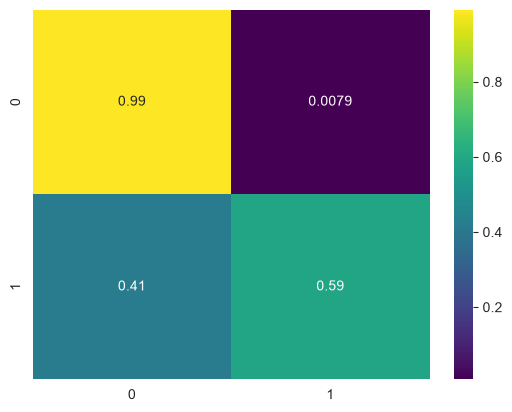

In [12]:
import seaborn as sns
cm = confusion_matrix(y_test, y_pred,normalize='true')
sns.heatmap(cm, annot=True,cmap='viridis')


In [13]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob[:,1], pos_label='positive')

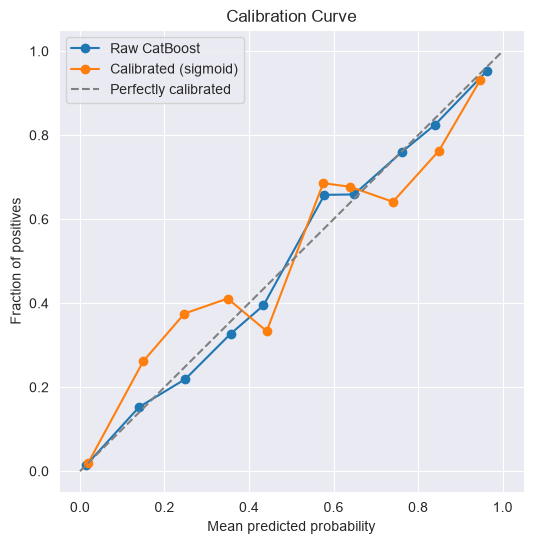

In [29]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
import matplotlib.pyplot as plt

# Wrap the already-trained model so CalibratedClassifierCV treats it as fixed
frozen_model = FrozenEstimator(cb_model)
calibrated_model = CalibratedClassifierCV(frozen_model, method='sigmoid')
calibrated_model.fit(X_train, y_train)

y_prob_calibrated = calibrated_model.predict_proba(X_test)[:, 1]

# Compare raw vs calibrated probabilities
prob_true_raw, prob_pred_raw = calibration_curve(y_test, y_prob[:, 1], n_bins=10, pos_label='positive')
prob_true_cal, prob_pred_cal = calibration_curve(y_test, y_prob_calibrated, n_bins=10, pos_label='positive')

plt.figure(figsize=(6, 6))
plt.plot(prob_pred_raw, prob_true_raw, marker='o', label='Raw CatBoost')
plt.plot(prob_pred_cal, prob_true_cal, marker='o', label='Calibrated (sigmoid)')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('Calibration Curve')
plt.legend()
plt.show()

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score, brier_score_loss

# Carve a validation set out of your existing training data
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=24
)

# Refit on the smaller train split, calibrate using validation
cb_model.fit(X_tr, y_tr, cat_features=cat_features)
frozen_model = FrozenEstimator(cb_model)
calibrated_model = CalibratedClassifierCV(frozen_model, method='sigmoid')
calibrated_model.fit(X_val, y_val)

y_prob_val = calibrated_model.predict_proba(X_val)[:, 1]

# Threshold scan: maximize F1 on validation set
thresholds = np.arange(0.01, 1.0, 0.001)
f1_scores = [f1_score(y_val, np.where(y_prob_val >= t, 'positive', 'negative'),
                       pos_label='positive', zero_division=0) for t in thresholds]

best_idx = np.argmax(f1_scores)
selected_threshold = thresholds[best_idx]
print(f"Selected threshold: {selected_threshold:.4f}")
print(f"Validation F1: {f1_scores[best_idx]:.4f}")

Selected threshold: 0.1700
Validation F1: 0.6831


In [31]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, fbeta_score

thresholds = np.arange(0.0, 1.01, 0.01)
precisions, recalls, f1s, f2s = [], [], [], []

for t in thresholds:
    y_pred_t = np.where(y_prob_calibrated >= t, 'positive', 'negative')
    precisions.append(precision_score(y_test, y_pred_t, pos_label='positive', zero_division=0))
    recalls.append(recall_score(y_test, y_pred_t, pos_label='positive', zero_division=0))
    f1s.append(f1_score(y_test, y_pred_t, pos_label='positive', zero_division=0))
    f2s.append(fbeta_score(y_test, y_pred_t, beta=2, pos_label='positive', zero_division=0))

# Option A: threshold that maximizes F2 (weights recall higher — fits your COVID use case)
best_f2_idx = np.argmax(f2s)
print(f"Threshold maximizing F2: {thresholds[best_f2_idx]:.2f}")

# Option B: lowest threshold that still guarantees a target recall
target_recall = 0.79
chosen_threshold = None
for t, r in zip(thresholds, recalls):
    if r >= target_recall:
        chosen_threshold = t
    else:
        break
print(f"Threshold for ≥{target_recall} recall: {chosen_threshold:.2f}")

Threshold maximizing F2: 0.05
Threshold for ≥0.79 recall: 0.02


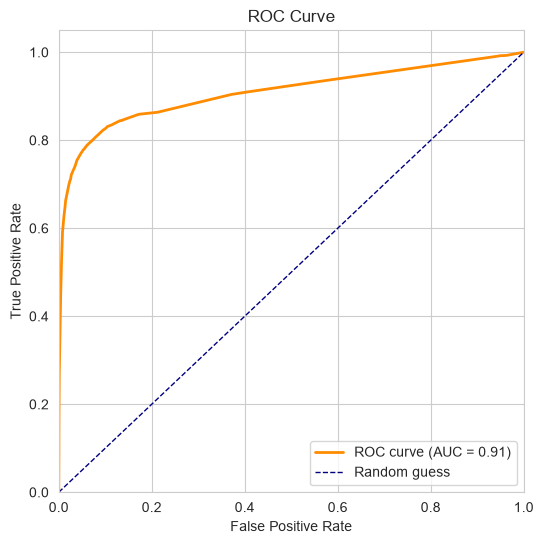

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import auc

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.1, 0.2],
    'iterations': [200, 500],
    'l2_leaf_reg': [1, 3, 5]
}

cb_model = CatBoostClassifier(cat_features= cat_features,verbose=False, random_state=24)

grid_search = GridSearchCV(
    estimator=cb_model,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV AUC score:", grid_search.best_score_)

best_model = grid_search.best_estimator_

In [168]:
best

{'params': {'depth': 8,
  'learning_rate': 0.2,
  'iterations': 500,
  'l2_leaf_reg': 3},
 'mean_auc': np.float64(0.9080416593708249)}

In [170]:
import pickle
import os

os.makedirs('models', exist_ok=True)

with open('models/cb_model.pkl', 'wb') as f:
    pickle.dump(cb_model, f)

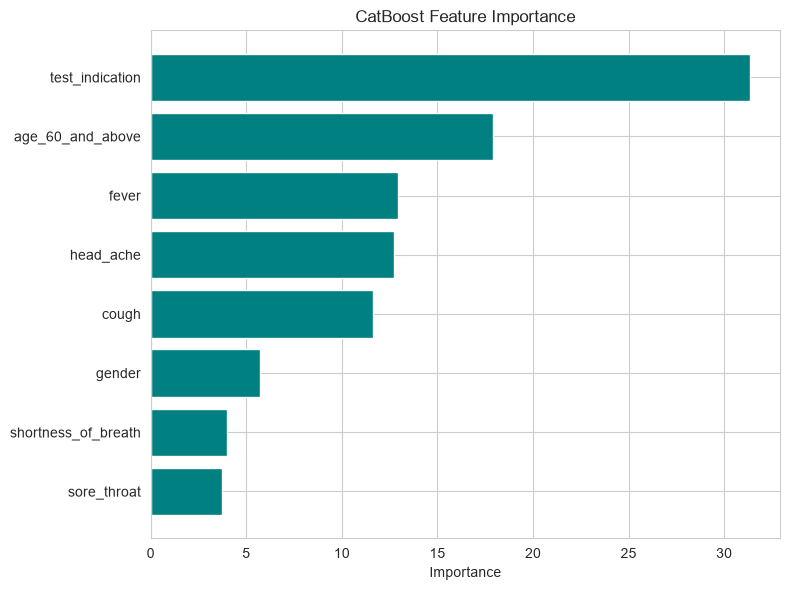

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

feature_importance = cb_model.get_feature_importance()
feature_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 6))
plt.barh(importance_df['feature'], importance_df['importance'], color='teal')
plt.xlabel('Importance')
plt.title('CatBoost Feature Importance')
plt.tight_layout()
plt.show()